# Data-Driven Educational Intervention Framework

این Notebook برای تبدیل خروجی مدل نهایی پیش‌بینی قصد تداوم استفاده از یادگیری الکترونیکی به یک چارچوب تصمیم‌یار برای مداخلات آموزشی ایجاد شده است.

در این مرحله هیچ مدل جدیدی آموزش داده نمی‌شود و مدل نهایی پژوهش تغییر نمی‌کند.

مدل نهایی از دو سازه زیر استفاده می‌کند:

- Expectation Confirmation (CON): تأیید انتظار
- Satisfaction (SAT): رضایت

و متغیر هدف آن:

- Continuance Intention (CI): قصد تداوم استفاده

خروجی مدل برای شناسایی دانشجویانی که ممکن است نیاز بیشتری به بررسی و حمایت داشته باشند استفاده می‌شود.

مقادیر CON و SAT در این چارچوب به‌عنوان predictive and diagnostic signals در نظر گرفته می‌شوند و نباید به‌عنوان شواهد اثر علّی تفسیر شوند.

مداخلات پیشنهادی نقش تصمیم‌یار

In [1]:
# در این سلول کتابخانه‌های موردنیاز و مسیرهای اصلی Notebook 7 به‌صورت خودکار تعریف می‌شوند.

from pathlib import Path
import os
import pandas as pd
import numpy as np
import joblib


# مسیر فعلی اجرای Notebook
CURRENT_DIR = Path.cwd().resolve()


# شناسایی خودکار ریشه پروژه
if CURRENT_DIR.name == "notebooks":

    PROJECT_ROOT = CURRENT_DIR.parent

elif (
    (CURRENT_DIR / "notebooks").exists()
    and (CURRENT_DIR / "data").exists()
):

    PROJECT_ROOT = CURRENT_DIR

else:

    raise FileNotFoundError(
        "Project root could not be detected. "
        "Please run this notebook from the project folder or the notebooks folder."
    )


PROCESSED_FOLDER = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

MODELS_FOLDER = os.path.join(
    PROJECT_ROOT,
    "models"
)

TABLES_FOLDER = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "tables"
)

FIGURES_FOLDER = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "figures"
)


B_DATA_PATH = os.path.join(
    PROCESSED_FOLDER,
    "dataset_B_processed.csv"
)

MODEL_PATH = os.path.join(
    MODELS_FOLDER,
    "Final_Linear_Regression_Model.joblib"
)


print("Project root:")
print(PROJECT_ROOT)

print("\nDataset B:")
print(B_DATA_PATH)

print("\nFinal model:")
print(MODEL_PATH)

print("\nTables folder:")
print(TABLES_FOLDER)

print("\nFigures folder:")
print(FIGURES_FOLDER)


print("\nPath check:")

print(
    "Dataset B exists:",
    os.path.exists(B_DATA_PATH)
)

print(
    "Final model exists:",
    os.path.exists(MODEL_PATH)
)

print(
    "Tables folder exists:",
    os.path.exists(TABLES_FOLDER)
)

print(
    "Figures folder exists:",
    os.path.exists(FIGURES_FOLDER)
)

Project root:
F:\E_Learning_Continuance_ML

Dataset B:
F:\E_Learning_Continuance_ML\data\processed\dataset_B_processed.csv

Final model:
F:\E_Learning_Continuance_ML\models\Final_Linear_Regression_Model.joblib

Tables folder:
F:\E_Learning_Continuance_ML\outputs\tables

Figures folder:
F:\E_Learning_Continuance_ML\outputs\figures

Path check:
Dataset B exists: True
Final model exists: True
Tables folder exists: True
Figures folder exists: True


In [2]:
# در این سلول Dataset B و مدل نهایی Linear Regression بدون آموزش مجدد بارگذاری می‌شوند.

df_intervention = pd.read_csv(
    B_DATA_PATH
)

final_model = joblib.load(
    MODEL_PATH
)


print(
    "Dataset B shape:",
    df_intervention.shape
)

print(
    "Final model:",
    type(final_model).__name__
)


required_columns = [
    "CON_score",
    "SAT_score",
    "CI_score"
]


print("\nRequired columns:")

for column in required_columns:

    if column in df_intervention.columns:
        print("✓ Found:", column)

    else:
        print("✗ Missing:", column)

Dataset B shape: (368, 32)
Final model: LinearRegression

Required columns:
✓ Found: CON_score
✓ Found: SAT_score
✓ Found: CI_score


In [3]:
# در این سلول مدل نهایی برای هر دانشجو مقدار Predicted CI را بدون آموزش مجدد محاسبه می‌کند.

X_intervention = df_intervention[
    [
        "CON_score",
        "SAT_score"
    ]
]


df_intervention[
    "Predicted_CI"
] = final_model.predict(
    X_intervention
)


print(
    df_intervention[
        [
            "CON_score",
            "SAT_score",
            "CI_score",
            "Predicted_CI"
        ]
    ].head()
)


print("\nPredicted CI summary:")

display(
    df_intervention[
        "Predicted_CI"
    ].describe()
)

   CON_score  SAT_score  CI_score  Predicted_CI
0   4.333333   4.666667  5.000000      4.487971
1   4.333333   4.333333  3.000000      4.290289
2   3.333333   2.666667  2.666667      3.110217
3   4.666667   5.000000  4.666667      4.749540
4   2.000000   3.000000  3.333333      3.052352

Predicted CI summary:


count    368.000000
mean       3.959239
std        0.614115
min        1.674598
25%        3.633355
50%        4.028720
75%        4.374664
max        4.813427
Name: Predicted_CI, dtype: float64

In [4]:
# در این سلول صدک‌های توزیع Predicted CI بررسی می‌شوند تا آستانه‌های مداخله بر اساس خود داده تعیین شوند.

predicted_ci_percentiles = df_intervention[
    "Predicted_CI"
].quantile(
    [
        0.10,
        0.20,
        0.25,
        0.50,
        0.75,
        0.80,
        0.90
    ]
)


print(
    "Predicted CI percentiles:"
)

display(
    predicted_ci_percentiles
)

Predicted CI percentiles:


0.10    3.244012
0.20    3.470863
0.25    3.633355
0.50    4.028720
0.75    4.374664
0.80    4.615745
0.90    4.813427
Name: Predicted_CI, dtype: float64

In [5]:
# در این سلول سطح اولویت مداخله بر اساس چارک اول و میانه Predicted CI تعیین می‌شود.

q25_predicted_ci = df_intervention[
    "Predicted_CI"
].quantile(0.25)

median_predicted_ci = df_intervention[
    "Predicted_CI"
].quantile(0.50)


def assign_intervention_priority(predicted_ci):

    if predicted_ci <= q25_predicted_ci:
        return "High Priority"

    elif predicted_ci <= median_predicted_ci:
        return "Moderate Priority"

    else:
        return "Routine Monitoring"


df_intervention[
    "Intervention_Priority"
] = df_intervention[
    "Predicted_CI"
].apply(
    assign_intervention_priority
)


print(
    "25th percentile threshold:",
    round(q25_predicted_ci, 4)
)

print(
    "Median threshold:",
    round(median_predicted_ci, 4)
)


print("\nIntervention priority distribution:")

priority_distribution = (
    df_intervention[
        "Intervention_Priority"
    ]
    .value_counts()
)


display(
    priority_distribution
)

25th percentile threshold: 3.6334
Median threshold: 4.0287

Intervention priority distribution:


Intervention_Priority
Moderate Priority     158
Routine Monitoring    112
High Priority          98
Name: count, dtype: int64

In [6]:
# در این سلول چارک اول CON و SAT برای شناسایی سطوح نسبتاً پایین این دو Predictor محاسبه می‌شود.

con_q25 = df_intervention[
    "CON_score"
].quantile(0.25)

sat_q25 = df_intervention[
    "SAT_score"
].quantile(0.25)


print(
    "CON 25th percentile:",
    round(con_q25, 4)
)

print(
    "SAT 25th percentile:",
    round(sat_q25, 4)
)


df_intervention[
    "Low_CON_Flag"
] = (
    df_intervention[
        "CON_score"
    ] <= con_q25
)


df_intervention[
    "Low_SAT_Flag"
] = (
    df_intervention[
        "SAT_score"
    ] <= sat_q25
)


print("\nLow CON:")
print(
    df_intervention[
        "Low_CON_Flag"
    ].value_counts()
)


print("\nLow SAT:")
print(
    df_intervention[
        "Low_SAT_Flag"
    ].value_counts()
)

CON 25th percentile: 3.3333
SAT 25th percentile: 3.5833

Low CON:
Low_CON_Flag
False    247
True     121
Name: count, dtype: int64

Low SAT:
Low_SAT_Flag
False    276
True      92
Name: count, dtype: int64


In [7]:
# در این سلول بر اساس وضعیت نسبی CON و SAT، پروفایل تشخیصی هر دانشجو تعیین می‌شود.

def assign_diagnostic_profile(row):

    if row["Low_CON_Flag"] and row["Low_SAT_Flag"]:
        return "Low CON + Low SAT"

    elif row["Low_CON_Flag"]:
        return "Low CON Only"

    elif row["Low_SAT_Flag"]:
        return "Low SAT Only"

    else:
        return "Neither Low"


df_intervention[
    "Diagnostic_Profile"
] = df_intervention.apply(
    assign_diagnostic_profile,
    axis=1
)


print("Diagnostic profile distribution:")

diagnostic_distribution = (
    df_intervention[
        "Diagnostic_Profile"
    ]
    .value_counts()
)

display(
    diagnostic_distribution
)

Diagnostic profile distribution:


Diagnostic_Profile
Neither Low          230
Low CON + Low SAT     75
Low CON Only          46
Low SAT Only          17
Name: count, dtype: int64

In [8]:
# در این سلول توزیع پروفایل‌های تشخیصی در هر سطح اولویت مداخله بررسی می‌شود.

priority_profile_table = pd.crosstab(
    df_intervention[
        "Intervention_Priority"
    ],
    df_intervention[
        "Diagnostic_Profile"
    ]
)


priority_order = [
    "High Priority",
    "Moderate Priority",
    "Routine Monitoring"
]


profile_order = [
    "Low CON + Low SAT",
    "Low CON Only",
    "Low SAT Only",
    "Neither Low"
]


priority_profile_table = (
    priority_profile_table
    .reindex(
        index=priority_order,
        columns=profile_order,
        fill_value=0
    )
)


display(
    priority_profile_table
)

Diagnostic_Profile,Low CON + Low SAT,Low CON Only,Low SAT Only,Neither Low
Intervention_Priority,,,,
High Priority,75,6,17,0
Moderate Priority,0,36,0,122
Routine Monitoring,0,4,0,108


In [9]:
# در این سلول درصد هر پروفایل تشخیصی در داخل هر سطح اولویت مداخله محاسبه می‌شود.

priority_profile_percent = (
    priority_profile_table
    .div(
        priority_profile_table.sum(axis=1),
        axis=0
    )
    * 100
)


priority_profile_percent = (
    priority_profile_percent
    .round(2)
)


display(
    priority_profile_percent
)

Diagnostic_Profile,Low CON + Low SAT,Low CON Only,Low SAT Only,Neither Low
Intervention_Priority,,,,
High Priority,76.53,6.12,17.35,0.00
Moderate Priority,0.00,22.78,0.00,77.22
Routine Monitoring,0.00,3.57,0.00,96.43


In [10]:
# در این سلول سطح اولویت و Signal Profile برای تولید پیشنهاد مداخله تصمیم‌یار با یکدیگر ترکیب می‌شوند.

df_intervention[
    "Signal_Profile"
] = df_intervention[
    "Diagnostic_Profile"
]


def assign_intervention_action(row):

    priority = row[
        "Intervention_Priority"
    ]

    profile = row[
        "Signal_Profile"
    ]


    if (
        priority == "High Priority"
        and profile == "Low CON + Low SAT"
    ):

        return "Combined Expectation and Satisfaction Review"


    elif (
        priority == "High Priority"
        and profile == "Low SAT Only"
    ):

        return "Satisfaction-Focused Review"


    elif (
        priority == "High Priority"
        and profile == "Low CON Only"
    ):

        return "Expectation-Alignment Review"


    elif (
        priority == "Moderate Priority"
        and profile == "Low CON Only"
    ):

        return "Expectation Check and Follow-up"


    elif priority == "Moderate Priority":

        return "Brief Check-in and Monitoring"


    else:

        return "Routine Monitoring"


df_intervention[
    "Suggested_Action"
] = df_intervention.apply(
    assign_intervention_action,
    axis=1
)


print("Suggested intervention actions:")

display(
    df_intervention[
        "Suggested_Action"
    ].value_counts()
)

Suggested intervention actions:


Suggested_Action
Brief Check-in and Monitoring                   122
Routine Monitoring                              112
Combined Expectation and Satisfaction Review     75
Expectation Check and Follow-up                  36
Satisfaction-Focused Review                      17
Expectation-Alignment Review                      6
Name: count, dtype: int64

In [11]:
# در این سلول تعداد دانشجویان در هر نوع اقدام پیشنهادی برای جدول نهایی چارچوب مداخله محاسبه می‌شود.

intervention_action_summary = (
    df_intervention
    .groupby(
        [
            "Intervention_Priority",
            "Signal_Profile",
            "Suggested_Action"
        ]
    )
    .size()
    .reset_index(
        name="N"
    )
)


intervention_action_summary[
    "Percent"
] = (
    intervention_action_summary[
        "N"
    ]
    / len(df_intervention)
    * 100
).round(2)


display(
    intervention_action_summary
)

,Intervention_Priority,Signal_Profile,Suggested_Action,N,Percent
0,High Priority,Low CON + Low SAT,Combined Expectation and Satisfaction Review,75,20.38
1,High Priority,Low CON Only,Expectation-Alignment Review,6,1.63
2,High Priority,Low SAT Only,Satisfaction-Focused Review,17,4.62
3,Moderate Priority,Low CON Only,Expectation Check and Follow-up,36,9.78
4,Moderate Priority,Neither Low,Brief Check-in and Monitoring,122,33.15
5,Routine Monitoring,Low CON Only,Routine Monitoring,4,1.09
6,Routine Monitoring,Neither Low,Routine Monitoring,108,29.35


In [12]:
# در این سلول برای هر نوع اقدام پیشنهادی، راهکار آموزشی، منطق تصمیم‌یار و برنامه پیگیری تعریف می‌شود.

intervention_framework = pd.DataFrame({

    "Suggested_Action": [

        "Combined Expectation and Satisfaction Review",

        "Expectation-Alignment Review",

        "Satisfaction-Focused Review",

        "Expectation Check and Follow-up",

        "Brief Check-in and Monitoring",

        "Routine Monitoring"
    ],


    "Primary_Signal": [

        "Low CON + Low SAT",

        "Low CON",

        "Low SAT",

        "Low CON",

        "No low CON/SAT signal despite moderate predicted CI",

        "No immediate high-priority signal"
    ],


    "Recommended_Intervention": [

        (
            "Conduct a structured review of both expectation-confirmation "
            "and satisfaction. Identify unmet expectations, clarify the "
            "actual capabilities and learning requirements of the platform, "
            "collect feedback on unsatisfactory learning experiences, and "
            "address modifiable barriers where feasible."
        ),

        (
            "Review the gap between the student's initial expectations and "
            "actual e-learning experience. Clarify course objectives, platform "
            "capabilities, learning procedures, expected workload, and available support."
        ),

        (
            "Collect focused feedback on the student's learning experience "
            "and sources of dissatisfaction, including usability, instructional "
            "experience, interaction, responsiveness, and perceived service quality."
        ),

        (
            "Perform a brief expectation-alignment check and provide clarification "
            "or guidance where expectations appear inconsistent with the actual "
            "learning environment. Reassess during follow-up."
        ),

        (
            "Conduct a brief human check-in to explore factors not captured by "
            "CON and SAT, such as temporary academic, technical, motivational, "
            "or contextual difficulties, followed by continued monitoring."
        ),

        (
            "Continue routine monitoring without intensive intervention. "
            "Provide normal access to support and reassess if predicted "
            "continuance intention declines in future measurements."
        )
    ],


    "Follow_Up": [

        "Reassess CON, SAT, and CI after the intervention period.",

        "Recheck CON and predicted CI after clarification or support.",

        "Reassess SAT and predicted CI after addressing identified concerns.",

        "Monitor changes in CON and predicted CI at the next assessment.",

        "Continue monitoring and escalate only if low CI persists or additional concerns emerge.",

        "Periodic reassessment as part of normal learning analytics monitoring."
    ],


    "Human_Oversight": [

        "Required",
        "Required",
        "Required",
        "Required",
        "Required",
        "Required"
    ]
})


display(
    intervention_framework
)

,Suggested_Action,Primary_Signal,Recommended_Intervention,Follow_Up,Human_Oversight
0,Combined Expectation and Satisfaction Review,Low CON + Low SAT,Conduct a structured review of both expectatio...,"Reassess CON, SAT, and CI after the interventi...",Required
1,Expectation-Alignment Review,Low CON,Review the gap between the student's initial e...,Recheck CON and predicted CI after clarificati...,Required
2,Satisfaction-Focused Review,Low SAT,Collect focused feedback on the student's lear...,Reassess SAT and predicted CI after addressing...,Required
3,Expectation Check and Follow-up,Low CON,Perform a brief expectation-alignment check an...,Monitor changes in CON and predicted CI at the...,Required
4,Brief Check-in and Monitoring,No low CON/SAT signal despite moderate predict...,Conduct a brief human check-in to explore fact...,Continue monitoring and escalate only if low C...,Required
5,Routine Monitoring,No immediate high-priority signal,Continue routine monitoring without intensive ...,Periodic reassessment as part of normal learni...,Required


In [13]:
# در این سلول تعداد و درصد مشاهده‌شده هر گروه با جزئیات راهکارهای پیشنهادی ترکیب می‌شود.

intervention_framework_results = (
    intervention_action_summary
    .merge(
        intervention_framework,
        on="Suggested_Action",
        how="left"
    )
)


intervention_framework_results = intervention_framework_results[
    [
        "Intervention_Priority",
        "Signal_Profile",
        "Suggested_Action",
        "N",
        "Percent",
        "Primary_Signal",
        "Recommended_Intervention",
        "Follow_Up",
        "Human_Oversight"
    ]
]


display(
    intervention_framework_results
)

,Intervention_Priority,Signal_Profile,Suggested_Action,N,Percent,Primary_Signal,Recommended_Intervention,Follow_Up,Human_Oversight
0,High Priority,Low CON + Low SAT,Combined Expectation and Satisfaction Review,75,20.38,Low CON + Low SAT,Conduct a structured review of both expectatio...,"Reassess CON, SAT, and CI after the interventi...",Required
1,High Priority,Low CON Only,Expectation-Alignment Review,6,1.63,Low CON,Review the gap between the student's initial e...,Recheck CON and predicted CI after clarificati...,Required
2,High Priority,Low SAT Only,Satisfaction-Focused Review,17,4.62,Low SAT,Collect focused feedback on the student's lear...,Reassess SAT and predicted CI after addressing...,Required
3,Moderate Priority,Low CON Only,Expectation Check and Follow-up,36,9.78,Low CON,Perform a brief expectation-alignment check an...,Monitor changes in CON and predicted CI at the...,Required
4,Moderate Priority,Neither Low,Brief Check-in and Monitoring,122,33.15,No low CON/SAT signal despite moderate predict...,Conduct a brief human check-in to explore fact...,Continue monitoring and escalate only if low C...,Required
5,Routine Monitoring,Low CON Only,Routine Monitoring,4,1.09,No immediate high-priority signal,Continue routine monitoring without intensive ...,Periodic reassessment as part of normal learni...,Required
6,Routine Monitoring,Neither Low,Routine Monitoring,108,29.35,No immediate high-priority signal,Continue routine monitoring without intensive ...,Periodic reassessment as part of normal learni...,Required


In [14]:
# در این سلول جدول نهایی چارچوب مداخلات آموزشی داده‌محور برای استفاده در مقاله ذخیره می‌شود.

INTERVENTION_TABLE_PATH = os.path.join(
    TABLES_FOLDER,
    "Intervention_Framework_Table.xlsx"
)


intervention_framework_results.to_excel(
    INTERVENTION_TABLE_PATH,
    index=False
)


print(
    "Intervention framework table saved:"
)

print(
    INTERVENTION_TABLE_PATH
)

Intervention framework table saved:
F:\E_Learning_Continuance_ML\outputs\tables\Intervention_Framework_Table.xlsx


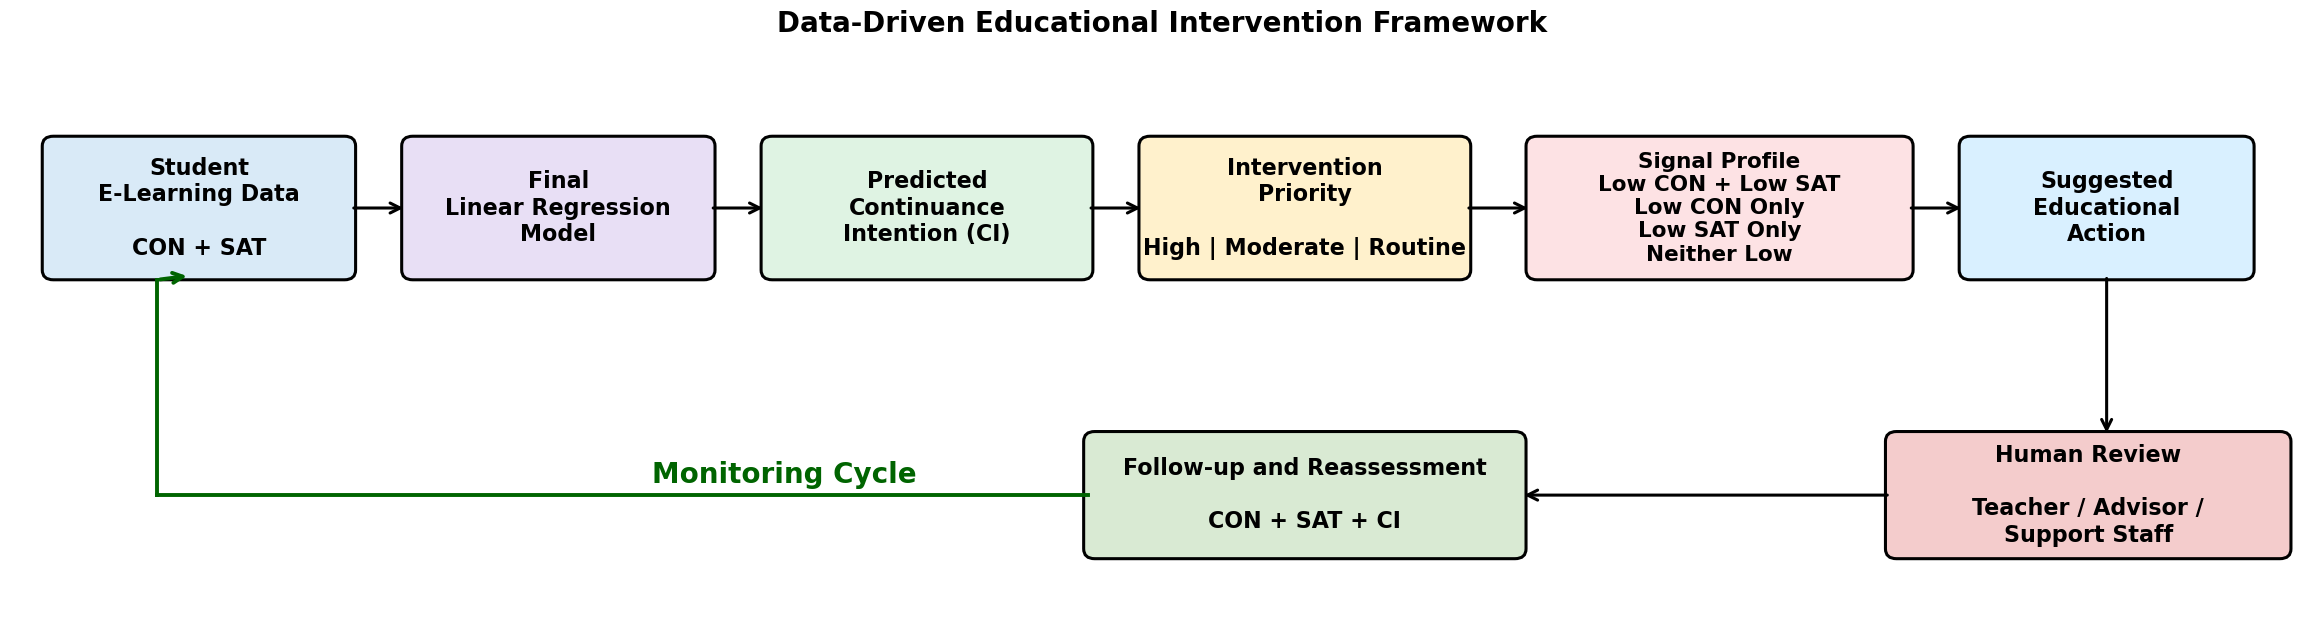

Framework figure saved:
F:\E_Learning_Continuance_ML\outputs\figures\Data_Driven_Intervention_Framework_Horizontal.png


In [15]:
# در این سلول فریم‌ورک مداخلات آموزشی داده‌محور با چیدمان نهایی و خط فیدبک L شکل رسم می‌شود.

import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


fig, ax = plt.subplots(figsize=(24, 6.6))
ax.set_xlim(0, 25)
ax.set_ylim(1.2, 8.2)
ax.axis("off")


def add_box(x, y, width, height, text, facecolor, edgecolor="black", fontsize=16):
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.05,rounding_size=0.12",
        linewidth=2.2,
        edgecolor=edgecolor,
        facecolor=facecolor
    )
    ax.add_patch(box)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
        wrap=True
    )


def add_arrow(x1, y1, x2, y2, color="black", lw=2.2):
    arrow = FancyArrowPatch(
        (x1, y1),
        (x2, y2),
        arrowstyle="->",
        mutation_scale=18,
        linewidth=lw,
        color=color
    )
    ax.add_patch(arrow)


# =========================================================
# ردیف اول
# =========================================================

top_y = 5.3
box_h = 1.65

# Box 1
add_box(
    0.4, top_y, 3.3, box_h,
    "Student\nE-Learning Data\n\nCON + SAT",
    facecolor="#D9EAF7",
    fontsize=16
)

# Box 2
add_box(
    4.3, top_y, 3.3, box_h,
    "Final\nLinear Regression\nModel",
    facecolor="#E8DFF5",
    fontsize=16
)

# Box 3
add_box(
    8.2, top_y, 3.5, box_h,
    "Predicted\nContinuance\nIntention (CI)",
    facecolor="#DFF3E3",
    fontsize=16
)

# Box 4
add_box(
    12.3, top_y, 3.5, box_h,
    "Intervention\nPriority\n\nHigh | Moderate | Routine",
    facecolor="#FFF1CC",
    fontsize=16
)

# Box 5
add_box(
    16.5, top_y, 4.1, box_h,
    "Signal Profile\nLow CON + Low SAT\nLow CON Only\nLow SAT Only\nNeither Low",
    facecolor="#FDE2E4",
    fontsize=15.5
)

# Box 6
add_box(
    21.2, top_y, 3.1, box_h,
    "Suggested\nEducational\nAction",
    facecolor="#D9F0FF",
    fontsize=16
)

# فلش‌های ردیف اول
center_y = top_y + box_h / 2
add_arrow(3.7, center_y, 4.3, center_y)
add_arrow(7.6, center_y, 8.2, center_y)
add_arrow(11.7, center_y, 12.3, center_y)
add_arrow(15.8, center_y, 16.5, center_y)
add_arrow(20.6, center_y, 21.2, center_y)


# =========================================================
# ردیف دوم
# =========================================================

bottom_y = 1.9
bottom_h = 1.45

# Follow-up
follow_x = 11.7
follow_w = 4.7
add_box(
    follow_x, bottom_y, follow_w, bottom_h,
    "Follow-up and Reassessment\n\nCON + SAT + CI",
    facecolor="#D9EAD3",
    fontsize=16
)

# Human Review
human_x = 20.4
human_w = 4.3
add_box(
    human_x, bottom_y, human_w, bottom_h,
    "Human Review\n\nTeacher / Advisor /\nSupport Staff",
    facecolor="#F4CCCC",
    fontsize=16
)


# =========================================================
# فلش‌های ارتباطی
# =========================================================

# Suggested Action -> Human Review
add_arrow(22.75, top_y, 22.75, bottom_y + bottom_h)

# Human Review -> Follow-up
add_arrow(
    human_x,
    bottom_y + bottom_h / 2,
    follow_x + follow_w,
    bottom_y + bottom_h / 2
)

# =========================================================
# فیدبک L شکل از Follow-up به Student Data
# =========================================================

feedback_y = bottom_y + bottom_h / 2
vertical_x = 1.6

# بخش افقی
ax.plot(
    [follow_x, vertical_x],
    [feedback_y, feedback_y],
    color="darkgreen",
    linewidth=2.8
)

# بخش عمودی
ax.plot(
    [vertical_x, vertical_x],
    [feedback_y, top_y - 0.05],
    color="darkgreen",
    linewidth=2.8
)

# فلش نهایی به Student Data
add_arrow(
    vertical_x,
    top_y - 0.05,
    1.95,
    top_y,
    color="darkgreen",
    lw=2.8
)

# متن روی خط فیدبک
ax.text(
    8.4,
    feedback_y + 0.08,
    "Monitoring Cycle",
    fontsize=20,
    fontweight="bold",
    color="darkgreen",
    ha="center",
    va="bottom"
)


# =========================================================
# عنوان
# =========================================================

ax.set_title(
    "Data-Driven Educational Intervention Framework",
    fontsize=20,
    fontweight="bold",
    pad=1
)

plt.subplots_adjust(top=0.93, bottom=0.06, left=0.02, right=0.98)

framework_path = os.path.join(
    FIGURES_FOLDER,
    "Data_Driven_Intervention_Framework_Horizontal.png"
)

plt.savefig(
    framework_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Framework figure saved:")
print(framework_path)

In [16]:
# در این سلول آستانه‌های داده‌محور مورد استفاده در چارچوب مداخله ذخیره می‌شوند.

intervention_thresholds = pd.DataFrame({

    "Threshold": [
        "Predicted_CI_Q25",
        "Predicted_CI_Median",
        "CON_Q25",
        "SAT_Q25"
    ],

    "Value": [
        q25_predicted_ci,
        median_predicted_ci,
        con_q25,
        sat_q25
    ],

    "Purpose": [
        "Upper boundary of High Priority",
        "Upper boundary of Moderate Priority",
        "Relative Low CON threshold",
        "Relative Low SAT threshold"
    ]
})


intervention_thresholds["Value"] = (
    intervention_thresholds["Value"]
    .round(4)
)


display(
    intervention_thresholds
)


THRESHOLDS_PATH = os.path.join(
    TABLES_FOLDER,
    "Intervention_Framework_Thresholds.xlsx"
)


intervention_thresholds.to_excel(
    THRESHOLDS_PATH,
    index=False
)


print("Intervention thresholds saved:")
print(THRESHOLDS_PATH)

,Threshold,Value,Purpose
0,Predicted_CI_Q25,3.6334,Upper boundary of High Priority
1,Predicted_CI_Median,4.0287,Upper boundary of Moderate Priority
2,CON_Q25,3.3333,Relative Low CON threshold
3,SAT_Q25,3.5833,Relative Low SAT threshold


Intervention thresholds saved:
F:\E_Learning_Continuance_ML\outputs\tables\Intervention_Framework_Thresholds.xlsx


In [17]:
# در این سلول وجود تمام خروجی‌های نهایی Notebook 7 بررسی می‌شود.

notebook_7_outputs = [

    os.path.join(
        TABLES_FOLDER,
        "Intervention_Framework_Table.xlsx"
    ),

    os.path.join(
        TABLES_FOLDER,
        "Intervention_Framework_Thresholds.xlsx"
    ),

    os.path.join(
        FIGURES_FOLDER,
        "Data_Driven_Intervention_Framework_Horizontal.png"
    )
]


print("Final Notebook 7 output check:\n")


all_outputs_found = True


for output_path in notebook_7_outputs:

    if os.path.exists(output_path):

        print(
            "✓ Found:",
            output_path
        )

    else:

        print(
            "✗ Missing:",
            output_path
        )

        all_outputs_found = False


print("\n--------------------------------")


if all_outputs_found:

    print(
        "Notebook 7 is complete."
    )

else:

    print(
        "Some Notebook 7 outputs are missing."
    )

Final Notebook 7 output check:

✓ Found: F:\E_Learning_Continuance_ML\outputs\tables\Intervention_Framework_Table.xlsx
✓ Found: F:\E_Learning_Continuance_ML\outputs\tables\Intervention_Framework_Thresholds.xlsx
✓ Found: F:\E_Learning_Continuance_ML\outputs\figures\Data_Driven_Intervention_Framework_Horizontal.png

--------------------------------
Notebook 7 is complete.


## Final Methodological Note

The intervention framework developed in this notebook is a data-driven
decision-support framework rather than a causal intervention model.

Intervention priority was determined from the distribution of predicted
Continuance Intention (CI) in Dataset B. The 25th percentile of predicted CI
was used to identify the highest-priority group, while the median separated
moderate-priority cases from routine monitoring.

Expectation Confirmation (CON) and Satisfaction (SAT) were subsequently used
as relative signal indicators. Their first-quartile values were used to define
Low CON and Low SAT profiles.

These thresholds are sample-derived and should not be interpreted as universal,
clinical, or psychometric cut-off values.

CON and SAT are treated as predictive and diagnostic signals rather than causal
determinants. Therefore, suggested educational actions require human review,
contextual assessment, follow-up, and empirical evaluation before any claim
about intervention effectiveness can be made.

No new predictive model was trained in this notebook. The previously selected
and externally validated Linear Regression model was used without modification